# Week 5 — Does fame buy you words? (exploration + validation)

Exercise 5.9 on the [course page](https://sunelehmann.com/socialgraphs2026-web/weeks/week5.html#go-nuts), openers 5 and 6 combined.
The production pipeline is `scripts/week5_analyze.py` (→ `data/processed/week5.json`). This notebook imports it, re-derives the key
numbers a second way, and keeps the **validation cells**:

1. token / type / hapax counts against the numbers we worked out in `week5/exercise_5_3.ipynb`
2. in- and out-degree against a hand count on `week1_edges.tsv`, and against networkx
3. the exact rarefaction formula against brute-force sampling
4. the fast Heaps curve against a direct count over the concatenated tokens
5. the Heaps fit (K, β) against `scipy.optimize.curve_fit`, checked by eye on the plotted curve
6. tokens against raw text, for `power`, `symbiote` and the words quoted in the hero figure's discussion
7. the in-browser computations (`src/js/week5_core.js`) against the Python output

This notebook builds on `exercise_5_3.ipynb` rather than starting blank: the page loader (its cell 6), the spaCy tokenization loop
(cell 56), the `CountVectorizer` setup (cells 116–125) and the raw-text checks (cells 95–98, 131–135) were lifted into the pipeline
script, and are called from there.

**Corpus, unless stated otherwise:** all 303 pages of `marvel_pages.zip`. **Tokenizer, unless stated otherwise:** spaCy
`en_core_web_sm` tokenizer, lowercased, punctuation and whitespace tokens dropped, stopwords kept. **Network:** the directed Week 1
network (303 nodes, 1,784 edges).

In [1]:
import sys, json, re, subprocess, random
from pathlib import Path
from collections import Counter
ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'week5' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import spearmanr
import week5_analyze as w5
%matplotlib inline

nodes, edges = w5.week1.load_raw()                 # the Week 1 loader, reused
ids, indeg, outdeg = w5.degrees(nodes, edges)
pages, readme = w5.load_pages()                    # exercise_5_3.ipynb, cell 6
nlp, spacy_version = w5.load_nlp()
tok = w5.tokenize_pages(nlp, pages, ids)           # exercise_5_3.ipynb, cell 56
page_tokens = [tok[i] for i in ids]
kept = w5.Stream([w for w, _ in page_tokens])
J = json.load(open(ROOT / 'data/processed/week5.json', encoding='utf-8'))
print(readme.splitlines()[0])
print(f'{len(pages)} pages, {len(edges)} directed edges, spaCy {spacy_version}')
print('week5.json generated', J['meta']['generatedAt'])

02805 shared playground - week 5 release (frozen snapshot, 2026-08-26)
303 pages, 1784 directed edges, spaCy 3.8.16
week5.json generated 2026-09-30T11:44:38.920359+00:00


## 1 · Validation: the counts, against `exercise_5_3.ipynb`

Same preprocessing as exercise 5.4, so the numbers should match exactly. `w5.NOTEBOOK` holds the numbers from the exercise notebook;
they are only ever compared with, never used.

In [2]:
hapax = sum(1 for c in kept.counts.values() if c == 1)
print(f'tokens {kept.N:,}  types {kept.V:,}  hapax {hapax:,} ({100 * hapax / kept.V:.1f}% of types)')
for w, c in kept.counts.most_common(10):
    print(f'  {w:5} {c:7,}  {100 * c / kept.N:.2f}%')
assert (kept.N, kept.V, hapax) == (w5.NOTEBOOK['tokens'], w5.NOTEBOOK['types'], w5.NOTEBOOK['hapax'])
pd.DataFrame(J['sanity'])

tokens 744,495  types 26,987  hapax 9,723 (36.0% of types)
  the    45,473  6.11%
  and    21,936  2.95%
  of     20,011  2.69%
  to     19,291  2.59%
  in     17,885  2.40%
  a      17,282  2.32%
  's      8,117  1.09%
  is      7,971  1.07%
  as      7,941  1.07%
  by      7,879  1.06%


,what,ours,notebook,ok
0,Tokens (spaCy),744495,744495,True
1,Types (spaCy),26987,26987,True
2,Hapax types (spaCy),9723,9723,True
3,Short descriptions: tokens / types / hapax,"[5379, 921, 696]","[5379, 921, 696]",True
4,Document-term matrix shape (CountVectorizer),"[303, 27583]","[303, 27583]",True
5,Non-zero cells,230310,230310,True
6,Five longest pages (CountVectorizer tokens),"[[Scarlet_Witch, 14203], [Betsy_Braddock, 1299...","[[Scarlet_Witch, 14203], [Betsy_Braddock, 1299...",True
7,Shortest page,"[Helix_(Marvel_Comics), 193]","[Helix_(Marvel_Comics), 193]",True
8,Terms after removing sklearn's stopwords,27284,27284,True
9,'power': spaCy tokens / raw regex,"[820, 821]","[820, 821]",True


Every row matches. There is still no single "true" vocabulary size: spaCy's tokenizer gives 26,987 types and our `CountVectorizer`
pattern 27,583 for the same pages (hyphenated words kept whole, digits and non-ASCII letters dropped). Every count below names its
tokenizer.

## 2 · Validation: in- and out-degree

Counted three ways: the pipeline (pandas `value_counts`), by hand from the raw lines of `week1_edges.tsv`, and with a networkx `DiGraph`
built roster-first so the 17 isolates stay in.

In [3]:
lines = [l.rstrip('\n').split('\t') for l in open(ROOT / 'data/raw/week1_edges.tsv', encoding='utf-8') if not l.startswith('#') and l.strip()]
D = nx.DiGraph(); D.add_nodes_from(ids); D.add_edges_from(lines)
assert len(lines) == D.number_of_edges() == 1784 and indeg.sum() == outdeg.sum() == 1784
rows = []
for c in ['Spider-Man', 'Hulk', 'Scarlet_Witch', 'Quasar_(character)', 'Miracleman_(character)', 'Brian_Braddock']:
    k = ids.index(c)
    hand_in, hand_out = sum(1 for s, t in lines if t == c), sum(1 for s, t in lines if s == c)
    rows.append({'character': c, 'pipeline in/out': (int(indeg[k]), int(outdeg[k])), 'by hand': (hand_in, hand_out),
                 'networkx': (D.in_degree(c), D.out_degree(c))})
    assert (indeg[k], outdeg[k]) == (hand_in, hand_out) == (D.in_degree(c), D.out_degree(c))
assert all(indeg[k] == D.in_degree(i) and outdeg[k] == D.out_degree(i) for k, i in enumerate(ids))
print('all 303 in/out-degrees agree with networkx; zero in-degree:', int((indeg == 0).sum()), '| isolates:', int(((indeg + outdeg) == 0).sum()))
pd.DataFrame(rows)

all 303 in/out-degrees agree with networkx; zero in-degree: 58 | isolates: 17


,character,pipeline in/out,by hand,networkx
0,Spider-Man,"(106, 9)","(106, 9)","(106, 9)"
1,Hulk,"(64, 10)","(64, 10)","(64, 10)"
2,Scarlet_Witch,"(28, 14)","(28, 14)","(28, 14)"
3,Quasar_(character),"(24, 3)","(24, 3)","(24, 3)"
4,Miracleman_(character),"(0, 0)","(0, 0)","(0, 0)"
5,Brian_Braddock,"(1, 11)","(1, 11)","(1, 11)"


## 3 · The hook: length against fame

Both variables are heavy-tailed, so the statistic is Spearman's. Pearson on the raw counts is shown only to say we don't use it.

In [4]:
L = kept.lengths
for name, deg in (('in-degree', indeg), ('out-degree', outdeg), ('total degree', indeg + outdeg)):
    r = spearmanr(L, deg)
    print(f'Spearman(length, {name:12}) = {r.statistic:.3f}  (p = {r.pvalue:.1e})')
print(f'Pearson on raw counts (not used): {np.corrcoef(L, indeg)[0, 1]:.3f}')
print(f'median page {np.median(L):.0f} tokens, longest {L.max():,} ({ids[int(L.argmax())]}), shortest {L.min()} ({ids[int(L.argmin())]})')
assert abs(spearmanr(L, indeg).statistic - J['hook']['spearman']['in']['rho']) < 1e-4
pd.concat([pd.DataFrame(J['hook']['outliers']['longForFame']).assign(group='long for its in-degree'),
           pd.DataFrame(J['hook']['outliers']['shortForFame']).assign(group='well linked but short')])

Spearman(length, in-degree   ) = 0.751  (p = 4.4e-56)
Spearman(length, out-degree  ) = 0.776  (p = 4.3e-62)
Spearman(length, total degree) = 0.828  (p = 1.1e-77)
Pearson on raw counts (not used): 0.655
median page 1261 tokens, longest 14,469 (Scarlet_Witch), shortest 195 (Helix_(Marvel_Comics))


,id,inDeg,outDeg,tokens,rankLength,rankIn,rankGap,group
0,Miracleman_(character),0,0,4471,48.0,274.5,226.5,long for its in-degree
1,Brian_Braddock,1,11,7446,24.0,225.0,201.0,long for its in-degree
2,Isaiah_Bradley,0,7,2085,104.0,274.5,170.5,long for its in-degree
3,Zombie_(comics),0,4,1617,129.0,274.5,145.5,long for its in-degree
4,Baymax,0,0,1610,130.0,274.5,144.5,long for its in-degree
0,Quasar_(character),24,3,1020,189.0,12.0,-177.0,well linked but short
1,Scarlet_Spider,8,3,956,204.0,64.0,-140.0,well linked but short
2,Jeffrey_Mace,7,1,1141,169.0,72.5,-96.5,well linked but short
3,Jericho_Drumm,13,7,1626,128.0,36.5,-91.5,well linked but short
4,Doctor_Nemesis,7,9,1459,141.0,72.5,-68.5,well linked but short


We read these ten pages. The long, unlinked ones (Miracleman, Brian Braddock, Isaiah Bradley) are mostly real-world publication
history; the well-linked short ones (Quasar, Scarlet Spider) open with "is the name of several superheroes" / "is an alias used by
several fictional characters": name pages that many articles point at and that hand the story on.

In [5]:
for p in ['Miracleman_(character)', 'Quasar_(character)', 'Scarlet_Spider']:
    print(f'[{p}]', pages[p][:330].replace('\n', ' '), '...\n')

[Miracleman_(character)] Miracleman (originally known as Marvelman), whose civilian name is Michael "Mike" Moran, is a British Golden Age comic book superhero appearing in comic books first published by  L. Miller & Son, Ltd. Created by Mick Anglo, the character first appeared in Marvelman #25 (February 1954). The character was revived by Dez Skinn in 1 ...

[Quasar_(character)] Quasar is the name of several superheroes appearing in American comic books published by Marvel Comics. They are noted for having worn the Quantum Bands, advanced ancient alien technology that grants the wearer manipulation of quantum energy.   Fictional character biography   Wendell Vaughn Wendell Vaughn is the longest-running  ...

[Scarlet_Spider] The Scarlet Spider is an alias used by several fictional characters appearing in American comic books published by Marvel Comics, most notably Ben Reilly and Kaine Parker, both of whom are genetic clones of Peter Parker, the superhero Spider-Man. His main costume i

## 4 · Length is not vocabulary: equal token budgets

Raw type counts grow with length on any text, so a page's type count can't be compared across pages. Two ways to give every page the
same budget of B tokens:

- **B tokens drawn at random from the whole page.** Exact expectation: Σ over types of 1 − C(n − f, B) / C(n, B).
- **B tokens in a row**, averaged over 20 windows.

**Validation:** the exact formula against brute-force sampling on one page.

In [6]:
words = page_tokens[ids.index('Spider-Man')][0]
exact = w5.rarefied_types(words, 500)
rng = random.Random(0)
brute = np.mean([len(set(rng.sample(words, 500))) for _ in range(4000)])
print(f'Spider-Man, 500 random tokens: exact {exact:.2f}, mean of 4000 samples {brute:.2f}')
assert abs(exact - brute) < 0.6
for b in J['budget']['budgets']:
    print(f"\nbudget {b['budget']} tokens, {b['nPages']} pages:")
    for r in b['rows']:
        print(f"  rho(in-degree, types) = {r['rho']:+.3f} (p = {r['p']:.3g})   rho(length, types) = {r['rhoLength']:+.3f}   {r['label']}")

Spider-Man, 500 random tokens: exact 290.82, mean of 4000 samples 290.73

budget 500 tokens, 272 pages:
  rho(in-degree, types) = +0.716 (p = 5.94e-44)   rho(length, types) = +0.994   all types on the page (no control)
  rho(in-degree, types) = +0.437 (p = 3.99e-14)   rho(length, types) = +0.651   500 tokens drawn at random from the whole page
  rho(in-degree, types) = -0.120 (p = 0.0483)   rho(length, types) = -0.029   500 tokens in a row (mean of 20 windows)

budget 1000 tokens, 193 pages:
  rho(in-degree, types) = +0.683 (p = 7.5e-28)   rho(length, types) = +0.992   all types on the page (no control)
  rho(in-degree, types) = +0.450 (p = 5.26e-11)   rho(length, types) = +0.676   1000 tokens drawn at random from the whole page
  rho(in-degree, types) = -0.025 (p = 0.734)   rho(length, types) = +0.013   1000 tokens in a row (mean of 20 windows)


The correlation with in-degree goes from +0.72 (no control) to +0.44 (random draw) to about zero (in a row). A scattered sample from a
long page touches more sections, so it looks richer; a continuous passage doesn't. "Controlling for length" has more than one meaning,
and the answer depends on which.

## 5 · Validation: the fast Heaps curve against a direct count

The pipeline never concatenates tokens for the shuffles. It stores, per page, each type's first index, and gets a type's first position
in any page order as (start of the earliest page containing it) + (first index there). The check: concatenate the tokens for real and
count.

In [7]:
order = w5.order_by(indeg, ids, descending=True)          # most-linked first, ties alphabetical
seen, n, direct, marks = set(), 0, [], set(kept.grid.tolist())
for p in order:
    for w in page_tokens[p][0]:
        seen.add(w); n += 1
        if n in marks:
            direct.append(len(seen))
fast = kept.curve(order)
assert direct == fast.tolist() == J['heaps']['kept']['curves']['in_desc']['V']
print(f'{len(direct)} grid points from n = {kept.grid[0]:,} to {kept.grid[-1]:,}: fast curve == direct count == week5.json')
print('first five pages in this order:', [ids[p] for p in order[:5]], [int(indeg[p]) for p in order[:5]])

120 grid points from n = 1,000 to 744,495: fast curve == direct count == week5.json
first five pages in this order: ['Spider-Man', 'Hulk', 'Wolverine_(character)', 'Doctor_Strange', 'Deadpool'] [106, 64, 60, 50, 33]


## 6 · Validation: the Heaps fit

The pipeline fits V = K·n^β by least squares on log V against log n, on 120 log-spaced values of n (so every decade of n weighs the
same). Checked here against `scipy.optimize.curve_fit` on the same log form (should agree to many digits), and against `curve_fit` on the
raw values, which weights the large-n end and so gives a lower β. The plot is the check by eye.

pipeline (log-log least squares): K = 6.812, beta = 0.6289, R2 = 0.9923
curve_fit on log V vs log n     : K = 6.812, beta = 0.6289
curve_fit on raw V vs n         : K = 23.979, beta = 0.5217   (weights large n; not used)
the curve bends: beta on the first half of the grid = 0.718, on the second half = 0.506


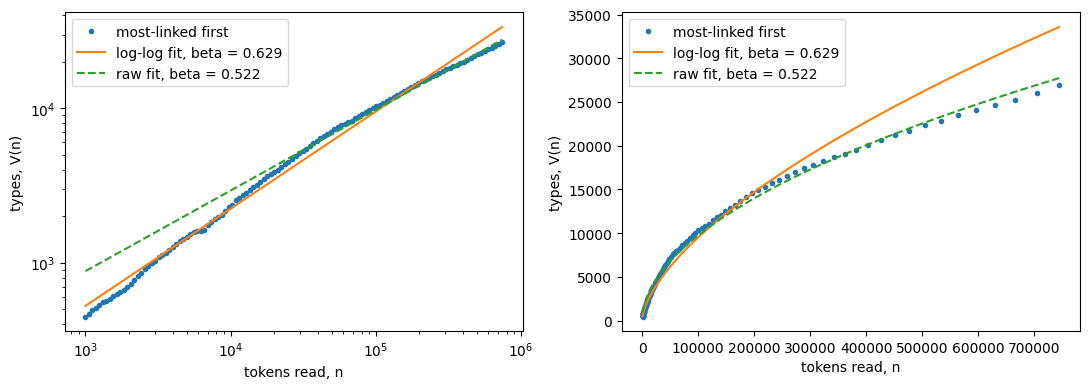

In [8]:
n, V = kept.grid.astype(float), fast.astype(float)
K, beta, r2 = w5.fit_power_law(n, V)
(a_log, b_log), _ = curve_fit(lambda x, a, b: a + b * x, np.log(n), np.log(V))
(K_raw, b_raw), _ = curve_fit(lambda x, K, b: K * x ** b, n, V, p0=[K, beta])
print(f'pipeline (log-log least squares): K = {K:.3f}, beta = {beta:.4f}, R2 = {r2:.4f}')
print(f'curve_fit on log V vs log n     : K = {np.exp(a_log):.3f}, beta = {b_log:.4f}')
print(f'curve_fit on raw V vs n         : K = {K_raw:.3f}, beta = {b_raw:.4f}   (weights large n; not used)')
assert abs(beta - b_log) < 1e-6 and abs(beta - J['heaps']['kept']['curves']['in_desc']['beta']) < 1e-5
half = len(n) // 2
print(f'the curve bends: beta on the first half of the grid = {w5.fit_power_law(n[:half], V[:half])[1]:.3f}, on the second half = {w5.fit_power_law(n[half:], V[half:])[1]:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a_, logy in zip(ax, (True, False)):
    a_.plot(n, V, 'o', ms=3, label='most-linked first')
    a_.plot(n, K * n ** beta, '-', label=f'log-log fit, beta = {beta:.3f}')
    a_.plot(n, K_raw * n ** b_raw, '--', label=f'raw fit, beta = {b_raw:.3f}')
    a_.set_xlabel('tokens read, n'); a_.set_ylabel('types, V(n)')
    if logy: a_.set_xscale('log'); a_.set_yscale('log')
    a_.legend()
plt.tight_layout(); plt.show()

The log-log line goes through the middle of the curve and misses both ends slightly: the curve is concave in log-log, so β depends on
the range it is fitted over (0.72 on the first half of the grid, 0.51 on the second). We report one β over a stated range (n from 1,000 to 744,495) and use it only to
compare page orders fitted over the same range.

## 7 · The null: random page orders

The JSON's band is 500 uniformly random page orders (seed 42). Re-drawn here with a different seed and only 40 shuffles, to check the band
isn't an accident of the seed.

In [9]:
rng = np.random.default_rng(7)
again = np.array([kept.curve(rng.permutation(len(ids))) for _ in range(40)])
betas = np.array([w5.fit_power_law(kept.grid, v)[1] for v in again])
S = J['heaps']['kept']
print(f"beta, 40 shuffles, seed 7 : {betas.mean():.4f} +- {betas.std():.4f}")
print(f"beta, 500 shuffles, seed 42: {S['null']['beta']['mean']:.4f} +- {S['null']['beta']['sd']:.4f}   (week5.json)")
mid = len(kept.grid) // 2 + 30
print(f"V at n = {kept.grid[mid]:,}: {again[:, mid].mean():.0f} here, {S['null']['mean'][mid]:.0f} in week5.json")
rows = []
for stop in ('kept', 'removed'):
    for key, c in J['heaps'][stop]['curves'].items():
        rows.append({'stopwords': stop, 'order': key, 'K': c['K'], 'beta': round(c['beta'], 4), 'p(beta)': c['pBeta'],
                     'avg gap %': round(100 * c['area'], 2), 'p(gap)': c['pArea'], 'below95': c['below95'], 'above95': c['above95']})
pd.DataFrame(rows)

beta, 40 shuffles, seed 7 : 0.6271 +- 0.0075
beta, 500 shuffles, seed 42: 0.6255 +- 0.0082   (week5.json)
V at n = 148,592: 12787 here, 12807 in week5.json


,stopwords,order,K,beta,p(beta),avg gap %,p(gap),below95,above95
0,kept,in_desc,6.8115,0.6289,0.6427,-2.76,0.1717,21,0
1,kept,in_asc,7.1903,0.6288,0.6467,2.62,0.1996,0,33
2,kept,out_desc,6.4601,0.6339,0.2874,-2.99,0.1397,20,0
3,kept,out_asc,7.5067,0.6249,0.9261,2.87,0.1637,0,32
4,kept,tot_desc,6.7723,0.6295,0.5928,-2.75,0.1737,24,0
5,kept,tot_asc,7.5563,0.6248,0.9222,3.48,0.0739,0,42
6,kept,len_desc,6.1794,0.6337,0.2974,-7.61,0.0020,77,0
7,kept,len_asc,7.2337,0.6256,0.9860,-0.07,0.9641,0,1
8,removed,in_desc,7.7444,0.6467,0.2295,-4.13,0.0479,27,0
9,removed,in_asc,9.1646,0.6362,0.8323,2.40,0.2395,0,32


**Reading the table.** No ordering has an unusual β. For the level, only page length (longest first) is clearly outside the band in both
stopword settings. Most-linked first sits about 3% under the random mean with stopwords kept (p = 0.17) and about 4% under with them
removed (p ≈ 0.05); out-degree, the third measure of the same idea, stays inside. With 16 curves tested, one or two p-values near 0.05 are
what chance gives.

### The tail: what the zero-in-degree pages add

In [10]:
T = S['tail']
print(f"{T['pages']} pages with in-degree 0, read last: {T['tokens']:,} tokens ({100 * T['tokenShare']:.1f}%), {T['newTypes']:,} new types")
print(f"random final stretch of the same length: {T['nullMean']:.0f} +- {T['nullSd']:.0f} (max {T['nullMax']}), p = {T['p']}")
LM = T['lengthMatched']
print(f"length-matched pages read last (in-degree shuffled within length deciles): {LM['mean']:.0f} +- {LM['sd']:.0f} (max {LM['max']}), p = {LM['p']}")
print(f"shortest pages read last, same number of tokens: {T['shortestLast']}")
new, _ = kept.new_types(order)
zero = [p for p in order if indeg[p] == 0]
assert int(new[zero].sum()) == T['newTypes']
top = sorted(zero, key=lambda p: -new[p])[:5]
for p in top:
    ex = S['examples']['in_desc'][order.tolist().index(p)]
    print(f'  {ids[p]:28} {int(new[p]):4} new types, e.g. {ex}')

58 pages with in-degree 0, read last: 46,347 tokens (6.2%), 1,104 new types
random final stretch of the same length: 734 +- 72 (max 931), p = 0.002
length-matched pages read last (in-degree shuffled within length deciles): 790 +- 55 (max 955), p = 0.002
shortest pages read last, same number of tokens: 779
  Miracleman_(character)        161 new types, e.g. ['miracleman', 'marvelman', 'moran', 'gargunza']
  Baymax                         55 new types, e.g. ['baymax', 'synthformer', 'adsit', 'dabai']
  Detroit_Steel                  45 new types, e.g. ['resilient', 'steelcorps', 'justine', 'mokk']
  Isaiah_Bradley                 42 new types, e.g. ['reinstein', 'pearl', 'koch', 'josiah']
  Solomon_Kane_(comics)          32 new types, e.g. ['kull', 'barbarians', 'poem', 'rowlands']


## 8 · The text wins: tokens against raw text

The pattern from `exercise_5_3.ipynb` §5.5.5 and §5.7.3, rerun here, then extended to the words the post quotes when it discusses the
hero figure (the example "new types" of the unlinked pages).

In [11]:
U = w5.unigram_check(nlp, pages, ids, 'power')
print(f"'power': tokens {U['tokenCount']}, raw regex {U['regexCount']}")
for m in U['mismatches']:
    print(f"  {m['page']}: tokens {m['tokenCount']}, regex {m['regexCount']}, culprit token(s) {m['culprits']}")
    print('   ', m['sentences'][0])
Cc = J['honesty']['column']
print(f"\n'symbiote' on Eddie_Brock: CountVectorizer column {Cc['matrixCount']}, raw regex {Cc['regexCount']}; separate columns: {Cc['culprits']}")
Hx = J['honesty']['hapax']
print(f"\nhapax types: {Hx['nHapax']:,}; the text has exactly one whole-word match for {Hx['agree']:,}, more than one for {Hx['regexFindsMore']}")
for e in Hx['examples']:
    print(f"  {e['type']!r}: 1 token, {e['regexCount']} matches in the text; the rest are inside {e['hiddenIn']}")
print(f"glued types (quote, bracket or em dash stuck to a word): {Hx['gluedTypes']}, of which hapax {Hx['gluedHapax']}")

'power': tokens 820, raw regex 821
  Doctor_Spectrum: tokens 24, regex 25, culprit token(s) ['Power"—an']
    …Doctor Spectrum. Courtesy of a phenomenon known as the "Wellspring of Power"—an interdimensional source of superhuman abilities—the Grandmaster incre…

'symbiote' on Eddie_Brock: CountVectorizer column 152, raw regex 155; separate columns: {'symbiote-empowered': 1, 'human-symbiote': 1, 'symbiote-possessed': 1}

hapax types: 9,723; the text has exactly one whole-word match for 9,648, more than one for 75
  'uncannyxmen': 1 token, 17 matches in the text; the rest are inside ['uncannyxmen.net']
  'ralston': 1 token, 2 matches in the text; the rest are inside ['ralston[sic']
  'salon': 1 token, 2 matches in the text; the rest are inside ['salon.com']
glued types (quote, bracket or em dash stuck to a word): 49, of which hapax 47


In [12]:
# the words quoted in the hero figure's discussion: token count vs whole-word regex on the page that introduces them
rows = []
for p in top[:3]:
    text = pages[ids[p]]
    toks = [t.lower_ for t in nlp.tokenizer(text)]
    for w in S['examples']['in_desc'][order.tolist().index(p)][:3]:
        rows.append({'page': ids[p], 'type': w, 'tokens': toks.count(w),
                     'regex': len(re.findall(r'\b' + re.escape(w) + r'\b', text, flags=re.IGNORECASE))})
df = pd.DataFrame(rows); df['agree'] = df['tokens'] == df['regex']; df

,page,type,tokens,regex,agree
0,Miracleman_(character),miracleman,76,76,True
1,Miracleman_(character),marvelman,46,46,True
2,Miracleman_(character),moran,20,20,True
3,Baymax,baymax,63,63,True
4,Baymax,synthformer,4,4,True
5,Baymax,adsit,4,4,True
6,Detroit_Steel,resilient,7,7,True
7,Detroit_Steel,steelcorps,4,4,True
8,Detroit_Steel,justine,4,4,True


All nine quoted words agree between tokens and text. The disagreements are elsewhere: `power"—an`, `symbiote-possessed`,
`uncannyxmen.net`, each a longer token the tokenizer kept whole. **When a raw-text regex and a tokenizer disagree, the text wins**, and any number derived from tokens
is only as good as the tokenizer's rules for the case at hand. For the Heaps curve this is small (49 glued types in 26,987) and it
affects every page order alike.

## 9 · Validation: the browser's computations

`src/js/week5_core.js` refits K and β for the curve on screen and ranks pages for the toy search box. `scripts/week5_validate_browser.mjs`
runs both in Node against the Python output (all 16 fits; 4 queries × 2 stopword settings against scikit-learn's `cosine_similarity`).

In [13]:
r = subprocess.run(['node', str(ROOT / 'scripts/week5_validate_browser.mjs')], capture_output=True, text=True, encoding='utf-8')
rep = json.loads(r.stdout)
print('checked:', rep['checked'], '| failures:', rep['failures'])
assert r.returncode == 0 and not rep['failures']

checked: {'fits': 16, 'searches': 8} | failures: []


## What this adds up to

- Fame buys length: Spearman ρ = 0.75 between in-degree and tokens.
- It doesn't buy a different Heaps curve: same β as random orders, and a level the shuffles can't separate from chance overall.
- Page length order does bend the curve; in-degree order is partly a length order.
- The 58 pages nobody links to add more new types at the end than length-matched pages do.
- One limitation: the random-order band can't separate fame from length for the whole curve. The length-matched shuffle was only run for
  the tail.